In [2]:
import pandas as pd 
import datetime as dt 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 


In [4]:
df = pd.read_excel('Online Retail.xlsx',parse_dates=['InvoiceDate'])

In [5]:
print(df.shape)

(541909, 8)


In [6]:

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [7]:

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
df = df.dropna(subset = ['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [9]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [10]:
df = df[df['Quantity']>0]

In [11]:
df = df[df['UnitPrice']>0]

In [12]:
df['Revenue'] = df['Quantity']*df['UnitPrice']

In [13]:
df.shape

(397884, 9)

In [15]:
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

In [18]:
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate',lambda x:(reference_date-x.max()).days),
    Frequency=('InvoiceNo','nunique'),
    Monetary=('Revenue','sum')
).reset_index()

In [19]:
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


In [20]:
print(rfm.describe())

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


In [23]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])


scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

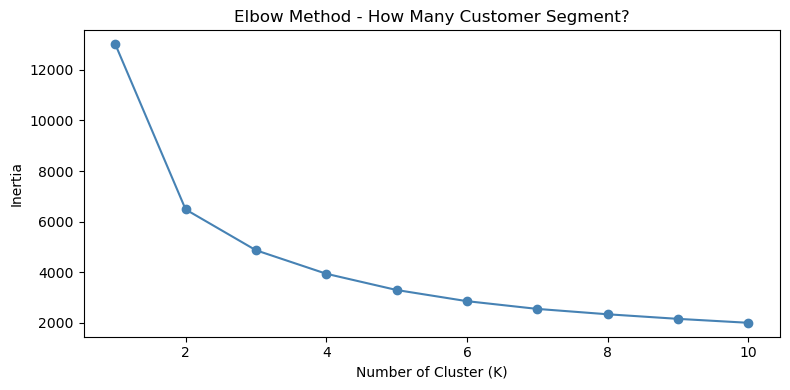

In [25]:
inertia = []
k_range = range(1,11)

for k in k_range:
    km=KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range, inertia, marker='o', color='steelblue')
plt.title('Elbow Method - How Many Customer Segment?')
plt.xlabel('Number of Cluster (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [27]:
kmeans=KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = rfm['Cluster'].astype(str)

summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print(summary)

         Recency  Frequency  Monetary
Cluster                              
0           18.1        2.1     551.8
1           12.1       13.7    8074.3
2           71.1        4.1    1802.8
3          182.5        1.3     343.5


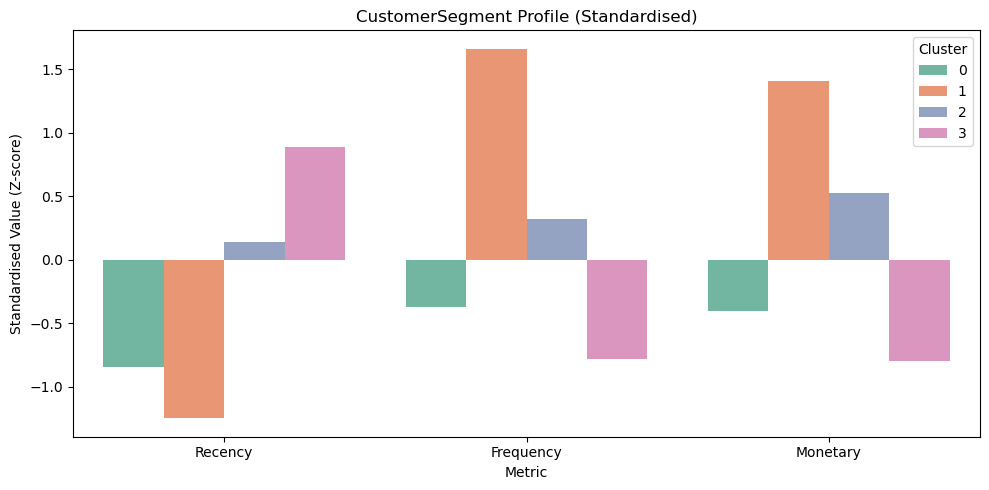

In [30]:
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled_df['Cluster'] = rfm['Cluster'].values

cluster_profile = rfm_scaled_df.groupby('Cluster').mean().reset_index()

rfm_melt = cluster_profile.melt(id_vars='Cluster', var_name='Metric', value_name='Value')

plt.figure(figsize=(10,5))
sns.barplot(data=rfm_melt, x='Metric', y='Value', hue='Cluster', palette='Set2')
plt.title('CustomerSegment Profile (Standardised)')
plt.ylabel('Standardised Value (Z-score)')
plt.tight_layout()
plt.show()
